In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import PchipInterpolator

R_gas = 8.314472

## Load data

In [2]:
janaf_NH3 = np.loadtxt("janaf_NH3.dat").T
NH3_t = janaf_NH3[0] # K
NH3_G = janaf_NH3[6] * 1e3 # J/mol

H2_t = np.array(NH3_t) # K
H2_G = np.zeros_like(H2_t) # H2 is in its standard state

N2_t = np.array(NH3_t) # K
N2_G = np.zeros_like(N2_t) # N2 is in its standard state

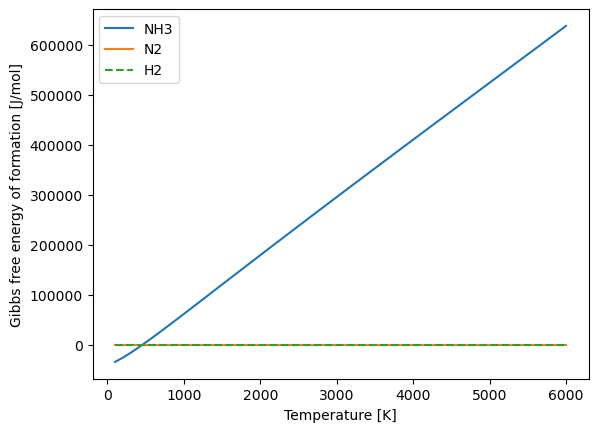

In [3]:
fig,ax = plt.subplots(1,1)

ax.plot(NH3_t, NH3_G, label="NH3")
ax.plot(N2_t,  N2_G , label="N2")
ax.plot(H2_t,  H2_G , label="H2", ls='dashed')

ax.set(xlabel="Temperature [K]", ylabel="Gibbs free energy of formation [J/mol]")
ax.legend()
plt.show()

## Interpolate

In [11]:
itp_NH3 = PchipInterpolator(NH3_t, NH3_G)
itp_N2 = PchipInterpolator(N2_t, N2_G)
itp_H2 = PchipInterpolator(H2_t, H2_G)

## Formulate reaction

In [12]:
def eval_deltaG(tmp):
    g_NH3 = itp_NH3(tmp)
    g_N2 = itp_N2(tmp)
    g_H2 = itp_H2(tmp)
    return g_NH3 - g_N2 - g_H2

def eval_Keq(tmp):
    return np.exp(-eval_deltaG(tmp)/(R_gas*tmp))

## Fit curve to log10(K_eq) values

In [13]:
tmp_arr = np.arange(200.0, 4000.0, 5)
keq_arr = np.array([eval_Keq(tmp) for tmp in tmp_arr])

In [14]:
def fit_line(x,a,b):
    return a + b*x
opt_line, _ = curve_fit(fit_line, tmp_arr, np.log10(keq_arr))
print(opt_line)

[-0.74371872 -0.00149708]


In [15]:
def fit_poly(x,a,b,c,d):
    return a + b*x + c*x**2 + d*x**3
opt_poly, _ = curve_fit(fit_poly, tmp_arr, np.log10(keq_arr))
print(opt_poly)

[ 5.42683731e+00 -1.27090940e-02  5.00742384e-06 -6.37451338e-10]


In [16]:
def fit_expo(x, a, b):
    return a/x - b
opt_expo, _ = curve_fit(fit_expo, tmp_arr, np.log10(keq_arr))
print(opt_expo)

[2664.015623      5.99238046]


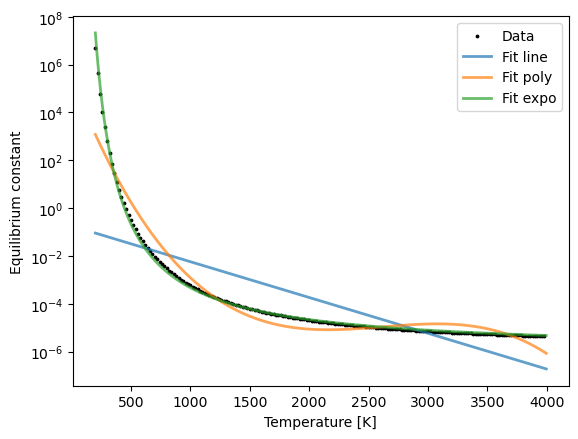

In [18]:
fig,ax = plt.subplots(1,1)

ax.scatter(tmp_arr[::4],  keq_arr[::4], s=3, label="Data", c='k')
ax.plot(tmp_arr,  10**fit_line(tmp_arr, *opt_line), lw=2, label="Fit line", alpha=0.7)
ax.plot(tmp_arr,  10**fit_poly(tmp_arr, *opt_poly), lw=2, label="Fit poly", alpha=0.7)
ax.plot(tmp_arr,  10**fit_expo(tmp_arr, *opt_expo), lw=2, label="Fit expo", alpha=0.7)

ax.set(xlabel="Temperature [K]", ylabel="Equilibrium constant")
ax.set_yscale("log")
ax.legend()
plt.show()